In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

%matplotlib inline

In [2]:
df = pd.read_csv(r'pandas/data/computer_prices_all.csv')
df.head()

,device_type,brand,model,release_year,os,form_factor,cpu_brand,cpu_model,cpu_tier,cpu_cores,...,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,wifi,bluetooth,weight_kg,warranty_months,price
0,Desktop,Samsung,Samsung Forge XDI,2022,Windows,ATX,Intel,Intel i5-11129,3,12,...,2560x1440,90,0,0,750,Wi-Fi 6,5.1,11.00,36,1383.99
1,Laptop,Samsung,Samsung Pro KM8,2022,Windows,Mainstream,Intel,Intel i7-11114,4,12,...,1920x1080,90,56,120,0,Wi-Fi 6,5.3,2.03,12,2274.99
2,Desktop,Lenovo,Lenovo Strix BIE,2024,macOS,SFF,AMD,AMD Ryzen 5 5168,2,8,...,3440x1440,120,0,0,850,Wi-Fi 6,5.0,7.00,24,1879.99
3,Desktop,Dell,Dell Cube AXR,2024,Windows,ATX,AMD,AMD Ryzen 5 7550,2,6,...,3440x1440,120,0,0,650,Wi-Fi 6,5.2,6.00,36,1331.99
4,Laptop,Gigabyte,Gigabyte Pro IX1,2024,Linux,Gaming,AMD,AMD Ryzen 7 6230,5,16,...,2560x1600,90,80,90,0,Wi-Fi 6,5.2,1.50,12,2681.99


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 33 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   device_type          100000 non-null  object 
 1   brand                100000 non-null  object 
 2   model                100000 non-null  object 
 3   release_year         100000 non-null  int64  
 4   os                   100000 non-null  object 
 5   form_factor          100000 non-null  object 
 6   cpu_brand            100000 non-null  object 
 7   cpu_model            100000 non-null  object 
 8   cpu_tier             100000 non-null  int64  
 9   cpu_cores            100000 non-null  int64  
 10  cpu_threads          100000 non-null  int64  
 11  cpu_base_ghz         100000 non-null  float64
 12  cpu_boost_ghz        100000 non-null  float64
 13  gpu_brand            100000 non-null  object 
 14  gpu_model            100000 non-null  object 
 15  gpu_tier          

In [4]:
# 결측치 확인
df.isnull().sum()

device_type            0
brand                  0
model                  0
release_year           0
os                     0
form_factor            0
cpu_brand              0
cpu_model              0
cpu_tier               0
cpu_cores              0
cpu_threads            0
cpu_base_ghz           0
cpu_boost_ghz          0
gpu_brand              0
gpu_model              0
gpu_tier               0
vram_gb                0
ram_gb                 0
storage_type           0
storage_gb             0
storage_drive_count    0
display_type           0
display_size_in        0
resolution             0
refresh_hz             0
battery_wh             0
charger_watts          0
psu_watts              0
wifi                   0
bluetooth              0
weight_kg              0
warranty_months        0
price                  0
dtype: int64

In [6]:
# model, cpu_model은 제거
df_copy = df.drop(['model','cpu_model','wifi', 'bluetooth', 'warranty_months', 'storage_drive_count', 'gpu_brand', 'cpu_brand'], axis=1)
df_copy.head()

,device_type,brand,release_year,os,form_factor,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,...,storage_gb,display_type,display_size_in,resolution,refresh_hz,battery_wh,charger_watts,psu_watts,weight_kg,price
0,Desktop,Samsung,2022,Windows,ATX,3,12,24,2.8,3.8,...,1024,LED,27.0,2560x1440,90,0,0,750,11.00,1383.99
1,Laptop,Samsung,2022,Windows,Mainstream,4,12,24,2.6,3.6,...,512,OLED,16.0,1920x1080,90,56,120,0,2.03,2274.99
2,Desktop,Lenovo,2024,macOS,SFF,2,8,16,2.6,3.6,...,512,LED,32.0,3440x1440,120,0,0,850,7.00,1879.99
3,Desktop,Dell,2024,Windows,ATX,2,6,12,2.6,3.6,...,512,IPS,27.0,3440x1440,120,0,0,650,6.00,1331.99
4,Laptop,Gigabyte,2024,Linux,Gaming,5,16,32,2.8,3.9,...,256,Mini-LED,15.6,2560x1600,90,80,90,0,1.50,2681.99


In [7]:
df_num_cols = df_copy.select_dtypes('number')
df_num_cols.head()

,release_year,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,display_size_in,refresh_hz,battery_wh,charger_watts,psu_watts,weight_kg,price
0,2022,3,12,24,2.8,3.8,2,6,16,1024,27.0,90,0,0,750,11.00,1383.99
1,2022,4,12,24,2.6,3.6,4,10,64,512,16.0,90,56,120,0,2.03,2274.99
2,2024,2,8,16,2.6,3.6,1,4,8,512,32.0,120,0,0,850,7.00,1879.99
3,2024,2,6,12,2.6,3.6,2,6,16,512,27.0,120,0,0,650,6.00,1331.99
4,2024,5,16,32,2.8,3.9,5,12,96,256,15.6,90,80,90,0,1.50,2681.99


In [8]:
df_num_cols.describe()

,release_year,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,storage_gb,display_size_in,refresh_hz,battery_wh,charger_watts,psu_watts,weight_kg,price
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,2022.320850,3.153490,10.515740,19.372700,2.591322,3.531310,2.991350,6.152180,39.706400,903.936000,20.126655,98.464860,41.813470,61.383450,272.520500,4.289699,1928.764220
std,2.025761,1.373175,5.044092,9.718426,0.336435,0.350024,1.459643,3.964926,31.902684,774.243654,6.709577,43.301652,35.868841,62.795034,354.686355,3.814628,580.492689
min,2018.000000,1.000000,4.000000,4.000000,2.000000,2.800000,1.000000,0.000000,8.000000,256.000000,13.300000,60.000000,0.000000,0.000000,0.000000,0.920000,372.990000
25%,2021.000000,2.000000,6.000000,12.000000,2.400000,3.300000,2.000000,4.000000,16.000000,512.000000,14.000000,60.000000,0.000000,0.000000,0.000000,1.500000,1503.990000
50%,2023.000000,3.000000,8.000000,16.000000,2.600000,3.500000,3.000000,6.000000,32.000000,512.000000,16.000000,90.000000,56.000000,65.000000,0.000000,2.000000,1863.990000
75%,2024.000000,4.000000,14.000000,24.000000,2.800000,3.800000,4.000000,8.000000,64.000000,1024.000000,27.000000,120.000000,70.000000,90.000000,650.000000,7.000000,2287.990000
max,2025.000000,6.000000,28.000000,56.000000,3.400000,4.500000,6.000000,16.000000,144.000000,4096.000000,34.000000,240.000000,99.000000,240.000000,1200.000000,16.000000,10984.990000


In [9]:
# 모든 수치형 컬럼의 이상치 확인하기
def get_outlier(col):
    iqr1 = df_num_cols[col].quantile(0.25)
    iqr3 = df_num_cols[col].quantile(0.75)
    iqr = iqr3 - iqr1
    upper_bound = iqr3 + iqr * 1.5
    lower_bound = iqr1 - iqr * 1.5
    df_outlier_upper = df_num_cols[df_num_cols[col].values > upper_bound]
    df_outlier_lower = df_num_cols[df_num_cols[col].values < lower_bound]
    
    df_outlier = df_num_cols[(df_num_cols[col].values>upper_bound)|(df_num_cols[col].values<lower_bound)]
    di = {
        '컬럼': col,
        '상한값': upper_bound,
        '최대값': df_num_cols[col].max(),
        '상한 이상치 개수':len(df_outlier_upper),
        '하한값': lower_bound,
        '최소값': df_num_cols[col].min(),
        '하한 이상치 개수': len(df_outlier_lower),
        '이상치 개수': len(df_outlier)
    }
    return di
    
    # print(f'컬럼: {col}, 상한값: {upper_bound}, 하한값: {lower_bound}')
    # print(f'상한 이상치 개수: {len(df_outlier_upper)}, 하한 이상치 개수: {len(df_outlier_lower)}')    
    # print(f'이상치 개수 : {len(df_outlier)}')
    # print()
    

res = []
for col in df_num_cols.columns:
    res.append(get_outlier(col))
    
df_outlier_info = pd.DataFrame(res)
df_outlier_info



,컬럼,상한값,최대값,상한 이상치 개수,하한값,최소값,하한 이상치 개수,이상치 개수
0,release_year,2028.50,2025.00,0,2016.50,2018.00,0,0
1,cpu_tier,7.00,6.00,0,-1.00,1.00,0,0
2,cpu_cores,26.00,28.00,200,-6.00,4.00,0,200
3,cpu_threads,42.00,56.00,3551,-6.00,4.00,0,3551
4,cpu_base_ghz,3.40,3.40,1978,1.80,2.00,0,1978
5,cpu_boost_ghz,4.55,4.50,0,2.55,2.80,0,0
6,gpu_tier,7.00,6.00,0,-1.00,1.00,0,0
7,vram_gb,14.00,16.00,3328,-2.00,0.00,0,3328
8,ram_gb,136.00,144.00,60,-56.00,8.00,0,60
9,storage_gb,1792.00,4096.00,14811,-256.00,256.00,0,14811


<Axes: >

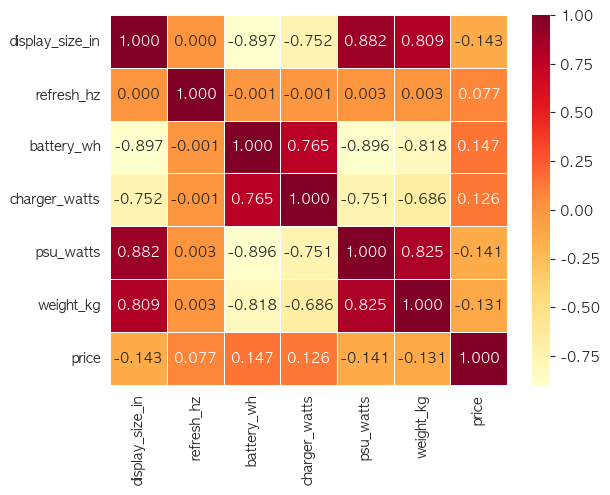

In [10]:
df_outlier_comp = df_copy[['display_size_in', 'refresh_hz', 'battery_wh', 'charger_watts', 'psu_watts', 'weight_kg', 'price']]
sns.heatmap(df_outlier_comp.corr(), annot=True, fmt='.3f', cmap='YlOrRd', linewidths=0.5)

In [11]:
# # price의 상한 이상치를 삭제해봄
di = get_outlier('price')
df_copy = df_copy[df_copy['price'] <= di['상한값']]
df_copy['price'].describe()

count    99024.000000
mean      1909.191375
std        541.972828
min        372.990000
25%       1499.990000
50%       1856.990000
75%       2271.990000
max       3462.990000
Name: price, dtype: float64

In [12]:
# price의 이상치를 상한값으로 대치해봄
# di = get_outlier('price')
# df_copy.loc[df_copy['price'] > di['상한값'], 'price'] = di['상한값']
# df_copy['price'].describe()

In [13]:
df_obj_cols = df_copy.drop(df_num_cols.columns, axis=1)
print(df_num_cols.columns.to_list())
print(df_obj_cols.columns.to_list())

['release_year', 'cpu_tier', 'cpu_cores', 'cpu_threads', 'cpu_base_ghz', 'cpu_boost_ghz', 'gpu_tier', 'vram_gb', 'ram_gb', 'storage_gb', 'display_size_in', 'refresh_hz', 'battery_wh', 'charger_watts', 'psu_watts', 'weight_kg', 'price']
['device_type', 'brand', 'os', 'form_factor', 'gpu_model', 'storage_type', 'display_type', 'resolution']


In [14]:
df_copy = df_copy.drop(['battery_wh', 'charger_watts', 'psu_watts', 'weight_kg'], axis=1)
df_copy.head()

,device_type,brand,release_year,os,form_factor,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,...,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,display_type,display_size_in,resolution,refresh_hz,price
0,Desktop,Samsung,2022,Windows,ATX,3,12,24,2.8,3.8,...,2,6,16,NVMe,1024,LED,27.0,2560x1440,90,1383.99
1,Laptop,Samsung,2022,Windows,Mainstream,4,12,24,2.6,3.6,...,4,10,64,NVMe,512,OLED,16.0,1920x1080,90,2274.99
2,Desktop,Lenovo,2024,macOS,SFF,2,8,16,2.6,3.6,...,1,4,8,NVMe,512,LED,32.0,3440x1440,120,1879.99
3,Desktop,Dell,2024,Windows,ATX,2,6,12,2.6,3.6,...,2,6,16,HDD,512,IPS,27.0,3440x1440,120,1331.99
4,Laptop,Gigabyte,2024,Linux,Gaming,5,16,32,2.8,3.9,...,5,12,96,NVMe,256,Mini-LED,15.6,2560x1600,90,2681.99


In [15]:
# # 다중공선성 제거
# df_copy = df_copy.drop(['device_type', 'cpu_boost_ghz', 'cpu_threads', 'cpu_cores'], axis=1)

# 디바이스 타입은 라벨인코딩
df_copy['device_type'] = np.where(df_copy['device_type'] == 'Desktop', 0, 1)
df_copy

,device_type,brand,release_year,os,form_factor,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,...,gpu_tier,vram_gb,ram_gb,storage_type,storage_gb,display_type,display_size_in,resolution,refresh_hz,price
0,0,Samsung,2022,Windows,ATX,3,12,24,2.8,3.8,...,2,6,16,NVMe,1024,LED,27.0,2560x1440,90,1383.99
1,1,Samsung,2022,Windows,Mainstream,4,12,24,2.6,3.6,...,4,10,64,NVMe,512,OLED,16.0,1920x1080,90,2274.99
2,0,Lenovo,2024,macOS,SFF,2,8,16,2.6,3.6,...,1,4,8,NVMe,512,LED,32.0,3440x1440,120,1879.99
3,0,Dell,2024,Windows,ATX,2,6,12,2.6,3.6,...,2,6,16,HDD,512,IPS,27.0,3440x1440,120,1331.99
4,1,Gigabyte,2024,Linux,Gaming,5,16,32,2.8,3.9,...,5,12,96,NVMe,256,Mini-LED,15.6,2560x1600,90,2681.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1,ASUS,2023,Windows,Mainstream,4,12,24,2.6,3.7,...,3,8,32,HDD,2048,LED,14.0,1920x1080,144,1712.99
99996,1,Lenovo,2018,Windows,Ultrabook,2,8,16,2.2,3.2,...,1,4,8,HDD,1024,LED,14.0,2560x1600,90,1258.99
99997,1,ASUS,2020,Windows,Mainstream,2,6,10,2.2,3.2,...,2,6,16,NVMe,1024,OLED,14.0,2560x1600,120,1686.99
99998,1,ASUS,2020,Windows,Mainstream,4,12,24,2.6,3.5,...,3,8,32,NVMe,256,OLED,15.6,2560x1600,120,2164.99


In [16]:
df_copy = pd.get_dummies(df_copy, drop_first=True, dtype='i1')
df_copy.head()

,device_type,release_year,cpu_tier,cpu_cores,cpu_threads,cpu_base_ghz,cpu_boost_ghz,gpu_tier,vram_gb,ram_gb,...,display_type_LED,display_type_Mini-LED,display_type_OLED,display_type_QLED,display_type_VA,resolution_2560x1440,resolution_2560x1600,resolution_2880x1800,resolution_3440x1440,resolution_3840x2160
0,0,2022,3,12,24,2.8,3.8,2,6,16,...,1,0,0,0,0,1,0,0,0,0
1,1,2022,4,12,24,2.6,3.6,4,10,64,...,0,0,1,0,0,0,0,0,0,0
2,0,2024,2,8,16,2.6,3.6,1,4,8,...,1,0,0,0,0,0,0,0,1,0
3,0,2024,2,6,12,2.6,3.6,2,6,16,...,0,0,0,0,0,0,0,0,1,0
4,1,2024,5,16,32,2.8,3.9,5,12,96,...,0,1,0,0,0,0,1,0,0,0


In [17]:
from sklearn.model_selection import train_test_split

# 독립변수(X)와 종속변수(y) 분리
X = df_copy.drop(columns=['price'])    # price를 제외한 컬럼을 X에
y = df_copy['price']                   # price를 y에

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


X shape: (99024, 95)
y shape: (99024,)


In [18]:
# 스케일링 (StandardScaler)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # train으로 fit + transform
X_test_scaled = scaler.transform(X_test)         # test는 transform만!

print('스케일링 완료')
print(f'Train 평균: {X_train_scaled.mean():.4f}, 표준편차: {X_train_scaled.std():.4f}')
print(f'Test 평균: {X_test_scaled.mean():.4f}, 표준편차: {X_test_scaled.std():.4f}')

스케일링 완료
Train 평균: -0.0000, 표준편차: 1.0000
Test 평균: -0.0002, 표준편차: 1.0000


In [19]:
# 평가 지표 함수 정의
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, r2_score
'''
MSE	    Mean Squared Error	                        평균 제곱 오차
RMSE	Root Mean Squared Error	                    평균 제곱근 오차(직관적)
MAE     Mean Absolute Error	                        평균 절대 오차 (오차의 절대값)
R²	    R-squared (Coefficient of Determination)	결정 계수, 모델이 데이터를 얼마나 잘 설명하는지 (0~1, 1에 가까울수록 좋음)
'''

def evaluate_model(name, y_true, y_pred):
    """모델 성능 평가 결과를 출력하고 딕셔너리로 반환"""
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f'[{name}]')
    print(f'  RMSE: {rmse:,.2f}')
    print(f'  MAE:  {mae:,.2f}')
    print(f'  R2:   {r2:.4f}')
    print()
    
    return {'모델': name, 'RMSE': round(rmse, 2), 'MAE': round(mae, 2), 'R2': round(r2, 4)}

# 결과 저장용 리스트
results = []

In [20]:
from sklearn.linear_model import LinearRegression

# 모델 생성 및 학습
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

# coef: 독립변수 1단위 증가 시 종속변수 예측값의 변화량
# intercept: 독립변수가 모두 0일 때 종속변수의 예측값

print(f'''coef
    {lr.coef_}
    intercept
    {lr.intercept_}
''')

# 예측
y_pred_lr = lr.predict(X_test_scaled)

# print('가중치 확인')
# for index, col in enumerate(X_train.columns):
#     print(f'{col} = {lr.coef_[index]}')

df_coef = pd.Series(lr.coef_, index=X_train.columns).abs().sort_values(ascending=False)
print(df_coef.head(15))


coef
    [ 3.36879326e+11  5.15741272e+01  2.11702167e+12  5.03461609e+01
 -5.03820496e+01 -2.61403448e+12 -5.86456299e-01  2.63470535e+02
  2.33369274e+01  4.33562279e+01  5.05270214e+01  1.76690578e+00
  4.25476189e+01 -2.63761950e+01  8.56346083e+01  1.24845285e+01
  3.23317766e-01  3.71342659e-01  7.39361978e+00  1.53251982e+01
  3.87706877e+01  2.06744945e+01  9.86339867e+00  3.80920579e+01
  1.33681695e+02  1.38317429e+12  9.76869854e+11  2.37701580e+01
 -1.26423616e-01  1.06842084e+12  6.71628071e+11  8.77891054e+11
  4.10534480e+01  3.30462646e+01  4.79980469e+00  1.42694092e+00
  8.50372314e-01 -6.49982452e-01 -1.25695801e+00 -1.91809082e+00
  2.57001495e+00 -1.83212280e-01 -8.10943604e-01 -6.76422119e-01
 -4.21264648e-01 -8.42693329e-01  4.43557739e+00  1.05636597e+00
 -9.65148926e-01 -9.56634521e-01 -2.51364136e+00 -3.16134644e+00
  8.03268433e+00  1.45639038e+00 -2.62765503e+00 -2.85426331e+00
 -5.28890991e+00 -6.48783875e+00  7.22253418e+00  1.69439697e+00
 -1.60052490e+00

In [21]:
# 평가
results.append(evaluate_model('Linear Regression', y_test, y_pred_lr))

[Linear Regression]
  RMSE: 180.90
  MAE:  138.75
  R2:   0.8902



  - price 이상치 삭제했을때
    - RMSE: 180.90
    - MAE:  138.75
    - R2:   0.8902
  
  - price 이상치 대치했을때
    - RMSE: 185.10
    - MAE:  140.40
    - R2:   0.8918

  